# 03. PCA y clustering de clientes

En este notebook se desarrolla la segmentación avanzada de clientes a partir de la tabla `dwh.customer_analytics`, construida previamente en PostgreSQL.

El objetivo es aplicar PCA y clustering para identificar segmentos de clientes con utilidad real de negocio, combinando:

1. Valor futuro esperado mediante CLTV.
2. Comportamiento de compra mediante variables RFM avanzadas.
3. Riesgo asociado a devoluciones.

Las variables de descuento fueron analizadas previamente, pero no se incorporan al PCA debido a su escasa presencia en los datos.

## IMPORTAR LIBRERÍAS

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from urllib.parse import quote_plus

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## CONEXIÓN BASE DE DATOS EN POSTGREE

In [3]:
# Parámetros de conexión a PostgreSQL
user = "postgres"
password = quote_plus("mimosa060401")
host = "localhost"
port = "5432"
database = "trabajo_final"

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"
)

In [4]:
# comporbar que se ha concetado bien y coge todos los datos de la base de datos

test_query = """
SELECT COUNT(*) AS num_customers
FROM dwh.customer_analytics;
"""

pd.read_sql(test_query, engine)

,num_customers
0,5750


## 1. Carga de la tabla analítica de clientes

Se carga desde PostgreSQL la tabla `dwh.customer_analytics`, que contiene una fila por cliente y recoge variables de CLTV, comportamiento de compra, rentabilidad y riesgo de devolución.

Esta tabla será la base para el análisis PCA y el clustering.

In [5]:
query = """
SELECT *
FROM dwh.customer_analytics;
"""

df = pd.read_sql(query, engine)

df.head()

,customer_id,analysis_date,first_purchase_date,second_purchase_date,last_purchase_date,days_to_second_purchase,recency_days,customer_lifetime_days,customer_lifetime_years,has_second_purchase,...,total_returned_amount,return_rate,num_returns,returned_orders,returned_sales_lines,quantity_returned,returned_cost,return_margin_impact,returned_order_rate,margin_impact_rate
0,5642,2026-02-07,2021-01-25,None,2021-01-25,NaN,1839,0,1.0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
1,2448,2026-02-07,2025-10-12,None,2025-10-12,NaN,118,0,1.0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
2,5665,2026-02-07,2024-11-15,None,2024-11-15,NaN,449,0,1.0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
3,5742,2026-02-07,2023-07-26,None,2023-07-26,NaN,927,0,1.0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
4,5743,2026-02-07,2023-07-30,None,2023-07-30,NaN,923,0,1.0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0


In [6]:
df.shape

(5750, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5750 entries, 0 to 5749
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5750 non-null   int64  
 1   analysis_date            5750 non-null   object 
 2   first_purchase_date      5750 non-null   object 
 3   second_purchase_date     750 non-null    object 
 4   last_purchase_date       5750 non-null   object 
 5   days_to_second_purchase  750 non-null    float64
 6   recency_days             5750 non-null   int64  
 7   customer_lifetime_days   5750 non-null   int64  
 8   customer_lifetime_years  5750 non-null   float64
 9   has_second_purchase      5750 non-null   int64  
 10  cltv                     5750 non-null   float64
 11  frequency_orders         5750 non-null   int64  
 12  purchase_frequency       5750 non-null   float64
 13  avg_ticket               5750 non-null   float64
 14  gross_revenue           

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,5750.0,2.877239e+03,1660.419383,1.00,1440.25,2877.50,4314.7500,5752.000000
days_to_second_purchase,750.0,1.028240e+02,97.873906,0.00,28.00,74.00,144.0000,601.000000
recency_days,5750.0,7.124572e+02,601.069036,39.00,131.00,460.00,1338.7500,1863.000000
customer_lifetime_days,5750.0,2.562226e+02,664.009977,0.00,0.00,0.00,0.0000,2183.000000
customer_lifetime_years,5750.0,1.571064e+00,1.482635,1.00,1.00,1.00,1.0000,5.976700
has_second_purchase,5750.0,1.304348e-01,0.336810,0.00,0.00,0.00,0.0000,1.000000
cltv,5750.0,6.543808e+02,1596.190366,0.00,24.00,52.00,120.0000,9573.440000
frequency_orders,5750.0,3.478261e+00,6.585678,1.00,1.00,1.00,1.0000,34.000000
purchase_frequency,5750.0,1.355534e+00,0.960265,1.00,1.00,1.00,1.0000,6.135600
avg_ticket,5750.0,2.102428e+02,203.873456,0.00,59.99,129.99,299.9900,1199.970000


## 2. Comprobaciones iniciales de calidad

Antes de aplicar PCA y clustering, se comprueba que la tabla mantiene una estructura correcta:

- Una fila por cliente.
- Ausencia de duplicados en `customer_id`.
- Ausencia de nulos en las variables principales.

In [9]:
num_filas = len(df)
num_clientes = df["customer_id"].nunique()
duplicados = df["customer_id"].duplicated().sum()

print("Número de filas:", num_filas)
print("Número de clientes únicos:", num_clientes)
print("Clientes duplicados:", duplicados)

Número de filas: 5750
Número de clientes únicos: 5750
Clientes duplicados: 0


## 3. Selección de variables para PCA y clustering

Para el modelo principal se seleccionan variables con capacidad real de segmentación.

Se excluyen las variables de descuento porque su presencia en los datos es residual. También se excluyen `total_margin` y `margin_rate` del PCA principal, ya que el margen presenta una relación casi directa con el CLTV y la tasa de margen es prácticamente constante.

La variable `margin_impact_rate` se conserva para el perfilado posterior de los clusters, pero no se incorpora directamente al PCA debido a su alta concentración en cero.

In [10]:
features_pca = [
    "cltv",
    "recency_days",
    "frequency_orders",
    "purchase_frequency",
    "customer_lifetime_days",
    "avg_ticket",
    "net_revenue",
    "return_rate",
    "returned_order_rate"
]

profile_features = [
    "cltv",
    "recency_days",
    "frequency_orders",
    "purchase_frequency",
    "customer_lifetime_days",
    "avg_ticket",
    "net_revenue",
    "total_margin",
    "margin_rate",
    "return_rate",
    "returned_order_rate",
    "margin_impact_rate",
    "total_returned_amount",
    "num_returns"
]

In [11]:
missing_pca_cols = [col for col in features_pca if col not in df.columns]
missing_profile_cols = [col for col in profile_features if col not in df.columns]

print("Columnas PCA que faltan:", missing_pca_cols)
print("Columnas perfilado que faltan:", missing_profile_cols)

Columnas PCA que faltan: []
Columnas perfilado que faltan: []


In [12]:
# crear matriz inicial

X = df[features_pca].copy()

X.head()

,cltv,recency_days,frequency_orders,purchase_frequency,customer_lifetime_days,avg_ticket,net_revenue,return_rate,returned_order_rate
0,15.96,1839,1,1.0,0,39.90,39.90,0.0,0.0
1,48.00,118,1,1.0,0,119.98,119.98,0.0,0.0
2,39.96,449,1,1.0,0,99.90,99.90,0.0,0.0
3,10.40,927,1,1.0,0,25.99,25.99,0.0,0.0
4,20.00,923,1,1.0,0,49.99,49.99,0.0,0.0


In [13]:
X.isnull().sum()

cltv                      0
recency_days              0
frequency_orders          0
purchase_frequency        0
customer_lifetime_days    0
avg_ticket                0
net_revenue               0
return_rate               0
returned_order_rate       0
dtype: int64

In [14]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,654.380826,1596.190366,0.0,24.00,52.00,120.00,9573.4400
recency_days,5750.0,712.457217,601.069036,39.0,131.00,460.00,1338.75,1863.0000
frequency_orders,5750.0,3.478261,6.585678,1.0,1.00,1.00,1.00,34.0000
purchase_frequency,5750.0,1.355534,0.960265,1.0,1.00,1.00,1.00,6.1356
customer_lifetime_days,5750.0,256.222609,664.009977,0.0,0.00,0.00,0.00,2183.0000
avg_ticket,5750.0,210.242758,203.873456,0.0,59.99,129.99,299.99,1199.9700
net_revenue,5750.0,1635.864113,3990.272273,0.0,59.99,129.99,299.99,23932.1500
return_rate,5750.0,0.066984,0.231010,0.0,0.00,0.00,0.00,1.0000
returned_order_rate,5750.0,0.091758,0.265594,0.0,0.00,0.00,0.00,1.0000


## 4. Tratamiento de variables antes del PCA

Las variables seleccionadas presentan escalas y distribuciones muy diferentes. En particular, las variables monetarias y de frecuencia muestran una fuerte asimetría, con pocos clientes de valor muy alto y muchos clientes de bajo valor.

Para evitar que estos valores extremos dominen el PCA, se aplican tres pasos:

1. Tratamiento de valores infinitos y nulos.
2. Winsorización al percentil 1 y 99.
3. Transformación logarítmica en variables monetarias y de volumen.
4. Estandarización final antes del PCA.

In [15]:
X = df[features_pca].copy()

# Sustituir infinitos por nulos y después imputar con 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X.head()

,cltv,recency_days,frequency_orders,purchase_frequency,customer_lifetime_days,avg_ticket,net_revenue,return_rate,returned_order_rate
0,15.96,1839,1,1.0,0,39.90,39.90,0.0,0.0
1,48.00,118,1,1.0,0,119.98,119.98,0.0,0.0
2,39.96,449,1,1.0,0,99.90,99.90,0.0,0.0
3,10.40,927,1,1.0,0,25.99,25.99,0.0,0.0
4,20.00,923,1,1.0,0,49.99,49.99,0.0,0.0


## winsoriacion

In [16]:
def winsorize_series(s, lower=0.01, upper=0.99):
    lower_bound = s.quantile(lower)
    upper_bound = s.quantile(upper)
    return s.clip(lower=lower_bound, upper=upper_bound)

winsor_cols = [
    "cltv",
    "recency_days",
    "frequency_orders",
    "purchase_frequency",
    "customer_lifetime_days",
    "avg_ticket",
    "net_revenue",
    "return_rate",
    "returned_order_rate"
]

X_winsor = X.copy()

for col in winsor_cols:
    X_winsor[col] = winsorize_series(X_winsor[col])

X_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,646.830474,1565.317503,0.0,24.00,52.00,120.00,6426.290400
recency_days,5750.0,712.437739,600.969836,43.0,131.00,460.00,1338.75,1856.000000
frequency_orders,5750.0,3.453739,6.494216,1.0,1.00,1.00,1.00,26.000000
purchase_frequency,5750.0,1.351349,0.943352,1.0,1.00,1.00,1.00,4.858816
customer_lifetime_days,5750.0,256.015231,663.417596,0.0,0.00,0.00,0.00,2137.510000
avg_ticket,5750.0,209.430727,200.932547,0.0,59.99,129.99,299.99,799.980000
net_revenue,5750.0,1616.986567,3913.081892,0.0,59.99,129.99,299.99,16064.777400
return_rate,5750.0,0.066984,0.231010,0.0,0.00,0.00,0.00,1.000000
returned_order_rate,5750.0,0.091758,0.265594,0.0,0.00,0.00,0.00,1.000000


In [17]:
# transformacion logaritmica 
X_transformed = X_winsor.copy()

log_cols = [
    "cltv",
    "recency_days",
    "frequency_orders",
    "purchase_frequency",
    "customer_lifetime_days",
    "avg_ticket",
    "net_revenue"
]

for col in log_cols:
    X_transformed[col] = np.log1p(X_transformed[col])

X_transformed.describe().T

,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,4.250427,1.972642,0.000000,3.218876,3.970292,4.795791,8.768308
recency_days,5750.0,6.033110,1.168605,3.784190,4.882802,6.133398,7.200238,7.526718
frequency_orders,5750.0,0.996141,0.785784,0.693147,0.693147,0.693147,0.693147,3.295837
purchase_frequency,5750.0,0.802825,0.288946,0.693147,0.693147,0.693147,0.693147,1.767948
customer_lifetime_days,5750.0,0.988600,2.552956,0.000000,0.000000,0.000000,0.000000,7.667865
avg_ticket,5750.0,4.716967,1.452140,0.000000,4.110710,4.875121,5.707077,6.685836
net_revenue,5750.0,5.104131,2.090009,0.000000,4.110710,4.875121,5.707077,9.684447
return_rate,5750.0,0.066984,0.231010,0.000000,0.000000,0.000000,0.000000,1.000000
returned_order_rate,5750.0,0.091758,0.265594,0.000000,0.000000,0.000000,0.000000,1.000000


In [18]:
# estandarización

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_transformed)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features_pca,
    index=df.index
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,-1.235726e-16,1.000087,-2.154875,-0.522974,-0.142023,0.276488,2.290469
recency_days,5750.0,-4.745190e-16,1.000087,-1.924616,-0.984429,0.085826,0.998823,1.278222
frequency_orders,5750.0,1.581730e-16,1.000087,-0.385628,-0.385628,-0.385628,-0.385628,2.926882
purchase_frequency,5750.0,-4.745190e-16,1.000087,-0.379611,-0.379611,-0.379611,-0.379611,3.340443
customer_lifetime_days,5750.0,0.000000e+00,1.000087,-0.387271,-0.387271,-0.387271,-0.387271,2.616514
avg_ticket,5750.0,-1.136868e-16,1.000087,-3.248569,-0.417529,0.108920,0.681887,1.355957
net_revenue,5750.0,5.931487e-17,1.000087,-2.442370,-0.475360,-0.109583,0.288515,2.191720
return_rate,5750.0,2.965744e-17,1.000087,-0.289985,-0.289985,-0.289985,-0.289985,4.039202
returned_order_rate,5750.0,-4.942906e-18,1.000087,-0.345513,-0.345513,-0.345513,-0.345513,3.419966


In [19]:
X_winsor.describe().T


,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,646.830474,1565.317503,0.0,24.00,52.00,120.00,6426.290400
recency_days,5750.0,712.437739,600.969836,43.0,131.00,460.00,1338.75,1856.000000
frequency_orders,5750.0,3.453739,6.494216,1.0,1.00,1.00,1.00,26.000000
purchase_frequency,5750.0,1.351349,0.943352,1.0,1.00,1.00,1.00,4.858816
customer_lifetime_days,5750.0,256.015231,663.417596,0.0,0.00,0.00,0.00,2137.510000
avg_ticket,5750.0,209.430727,200.932547,0.0,59.99,129.99,299.99,799.980000
net_revenue,5750.0,1616.986567,3913.081892,0.0,59.99,129.99,299.99,16064.777400
return_rate,5750.0,0.066984,0.231010,0.0,0.00,0.00,0.00,1.000000
returned_order_rate,5750.0,0.091758,0.265594,0.0,0.00,0.00,0.00,1.000000


In [20]:
X_transformed.describe().T


,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,4.250427,1.972642,0.000000,3.218876,3.970292,4.795791,8.768308
recency_days,5750.0,6.033110,1.168605,3.784190,4.882802,6.133398,7.200238,7.526718
frequency_orders,5750.0,0.996141,0.785784,0.693147,0.693147,0.693147,0.693147,3.295837
purchase_frequency,5750.0,0.802825,0.288946,0.693147,0.693147,0.693147,0.693147,1.767948
customer_lifetime_days,5750.0,0.988600,2.552956,0.000000,0.000000,0.000000,0.000000,7.667865
avg_ticket,5750.0,4.716967,1.452140,0.000000,4.110710,4.875121,5.707077,6.685836
net_revenue,5750.0,5.104131,2.090009,0.000000,4.110710,4.875121,5.707077,9.684447
return_rate,5750.0,0.066984,0.231010,0.000000,0.000000,0.000000,0.000000,1.000000
returned_order_rate,5750.0,0.091758,0.265594,0.000000,0.000000,0.000000,0.000000,1.000000


In [21]:
X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cltv,5750.0,-1.235726e-16,1.000087,-2.154875,-0.522974,-0.142023,0.276488,2.290469
recency_days,5750.0,-4.745190e-16,1.000087,-1.924616,-0.984429,0.085826,0.998823,1.278222
frequency_orders,5750.0,1.581730e-16,1.000087,-0.385628,-0.385628,-0.385628,-0.385628,2.926882
purchase_frequency,5750.0,-4.745190e-16,1.000087,-0.379611,-0.379611,-0.379611,-0.379611,3.340443
customer_lifetime_days,5750.0,0.000000e+00,1.000087,-0.387271,-0.387271,-0.387271,-0.387271,2.616514
avg_ticket,5750.0,-1.136868e-16,1.000087,-3.248569,-0.417529,0.108920,0.681887,1.355957
net_revenue,5750.0,5.931487e-17,1.000087,-2.442370,-0.475360,-0.109583,0.288515,2.191720
return_rate,5750.0,2.965744e-17,1.000087,-0.289985,-0.289985,-0.289985,-0.289985,4.039202
returned_order_rate,5750.0,-4.942906e-18,1.000087,-0.345513,-0.345513,-0.345513,-0.345513,3.419966


## 5. Análisis de Componentes Principales (PCA)

Una vez tratadas las variables y estandarizadas, se aplica PCA para reducir la dimensionalidad del conjunto de datos.

El PCA permite transformar las variables originales en nuevas componentes no correlacionadas entre sí, ordenadas según la cantidad de varianza que explican.

Este paso es útil porque algunas variables del análisis están relacionadas entre sí, especialmente las variables de valor económico y comportamiento de compra. La reducción de dimensionalidad permite aplicar clustering sobre una representación más compacta y estable de los clientes.

In [22]:
# Aplicar PCA con todas las componentes posibles
pca_full = PCA()

pca_full.fit(X_scaled_df)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance
})

pca_summary

,component,explained_variance,cumulative_variance
0,PC1,0.595190,0.595190
1,PC2,0.263316,0.858506
2,PC3,0.090716,0.949222
3,PC4,0.044427,0.993649
4,PC5,0.004026,0.997674
5,PC6,0.002246,0.999921
6,PC7,0.000063,0.999984
7,PC8,0.000013,0.999997
8,PC9,0.000003,1.000000


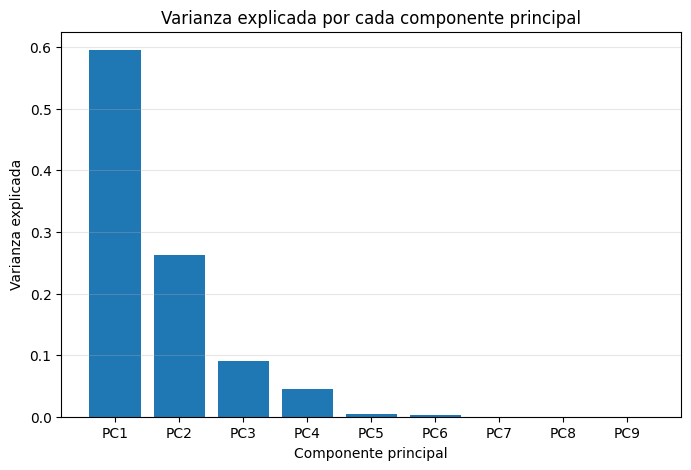

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    pca_summary["component"],
    pca_summary["explained_variance"]
)

plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada por cada componente principal")
plt.grid(axis="y", alpha=0.3)
plt.show()

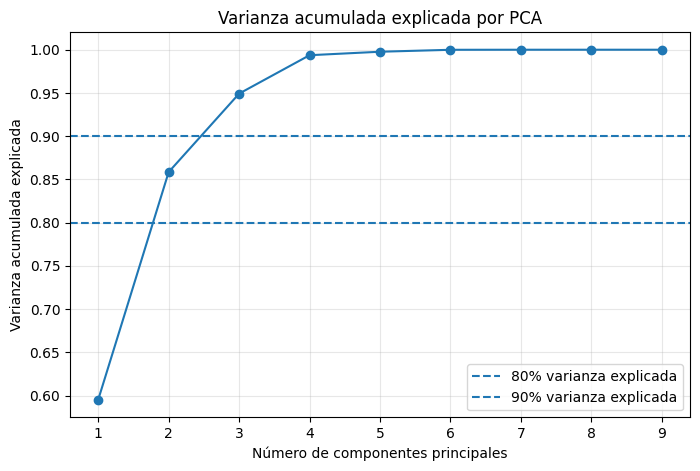

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.80, linestyle="--", label="80% varianza explicada")
plt.axhline(y=0.90, linestyle="--", label="90% varianza explicada")

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada explicada")
plt.title("Varianza acumulada explicada por PCA")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [25]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Componentes necesarias para explicar al menos el 80%:", n_components_80)
print("Componentes necesarias para explicar al menos el 90%:", n_components_90)

Componentes necesarias para explicar al menos el 80%: 2
Componentes necesarias para explicar al menos el 90%: 3


El análisis PCA muestra que las dos primeras componentes principales explican aproximadamente el 85% de la variabilidad total, superando el umbral mínimo del 80%. No obstante, se decidió conservar tres componentes para el clustering final, ya que con ellas se alcanza aproximadamente el 95% de varianza acumulada. Esta elección permite mantener una representación compacta del comportamiento de los clientes sin perder información relevante para la segmentación.

La primera componente concentra la mayor parte de la variabilidad, lo que indica que varias variables de valor económico y comportamiento de compra están fuertemente relacionadas. La segunda y tercera componentes añaden dimensiones complementarias, probablemente asociadas a patrones de actividad, frecuencia y riesgo de devolución.

## 6. PCA final con tres componentes

A partir del análisis de varianza explicada, se seleccionan tres componentes principales para el clustering final. Estas tres componentes explican aproximadamente el 95% de la variabilidad total, permitiendo reducir la dimensionalidad del problema sin perder información relevante.

La visualización se realizará principalmente con las dos primeras componentes, mientras que el clustering se entrenará utilizando las tres componentes seleccionadas.

In [26]:
# PCA final con tres componentes
n_components_final = 3

pca = PCA(n_components=n_components_final)

X_pca = pca.fit_transform(X_scaled_df)

pca_cols = [f"PC{i+1}" for i in range(n_components_final)]

df_pca = pd.DataFrame(
    X_pca,
    columns=pca_cols,
    index=df.index
)

df_pca.head()

,PC1,PC2,PC3
0,-1.373791,-0.604085,0.872384
1,-0.250955,-0.505811,-1.233808
2,-0.572525,-0.646326,-0.161841
3,-1.537003,-0.395085,0.248921
4,-1.125747,-0.565275,0.335072


In [27]:
# Añadir customer_id al dataframe PCA

df_pca["customer_id"] = df["customer_id"].values

df_pca.head()

,PC1,PC2,PC3,customer_id
0,-1.373791,-0.604085,0.872384,5642
1,-0.250955,-0.505811,-1.233808,2448
2,-0.572525,-0.646326,-0.161841,5665
3,-1.537003,-0.395085,0.248921,5742
4,-1.125747,-0.565275,0.335072,5743


In [28]:
# Ver la varianza final de esas tres componentes

pca_final_summary = pd.DataFrame({
    "component": pca_cols,
    "explained_variance": pca.explained_variance_ratio_,
    "cumulative_variance": pca.explained_variance_ratio_.cumsum()
})

pca_final_summary

,component,explained_variance,cumulative_variance
0,PC1,0.595190,0.595190
1,PC2,0.263316,0.858506
2,PC3,0.090716,0.949222


- PC1 resume la mayor parte de la información del cliente.

- PC2 añade una dimensión distinta, sobre todo relacionada con devoluciones.

- PC3 añade otra dimensión casi independiente, relacionada con recencia/inactividad.

## 7. Interpretación de las componentes principales

Para interpretar el PCA se analizan los *loadings*, que indican el peso de cada variable original dentro de cada componente principal.

Las variables con mayor peso absoluto en una componente son las que más contribuyen a su significado.

In [29]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_pca,
    columns=pca_cols
)

loadings

,PC1,PC2,PC3
cltv,0.422975,-0.033243,0.100351
recency_days,-0.178659,-0.166324,0.964421
frequency_orders,0.378478,0.287876,0.087898
purchase_frequency,0.375105,0.286523,0.098024
customer_lifetime_days,0.377638,0.285947,0.087007
avg_ticket,0.345436,-0.311526,0.070493
net_revenue,0.421303,-0.078912,0.091162
return_rate,-0.207389,0.548968,0.085466
returned_order_rate,-0.150934,0.565559,0.119721


In [30]:
for pc in pca_cols:
    print(f"\n{pc} - variables con mayor peso absoluto:")
    print(
        loadings[pc]
        .sort_values(key=lambda x: abs(x), ascending=False)
        .head(6)
    )


PC1 - variables con mayor peso absoluto:
cltv                      0.422975
net_revenue               0.421303
frequency_orders          0.378478
customer_lifetime_days    0.377638
purchase_frequency        0.375105
avg_ticket                0.345436
Name: PC1, dtype: float64

PC2 - variables con mayor peso absoluto:
returned_order_rate       0.565559
return_rate               0.548968
avg_ticket               -0.311526
frequency_orders          0.287876
purchase_frequency        0.286523
customer_lifetime_days    0.285947
Name: PC2, dtype: float64

PC3 - variables con mayor peso absoluto:
recency_days           0.964421
returned_order_rate    0.119721
cltv                   0.100351
purchase_frequency     0.098024
net_revenue            0.091162
frequency_orders       0.087898
Name: PC3, dtype: float64


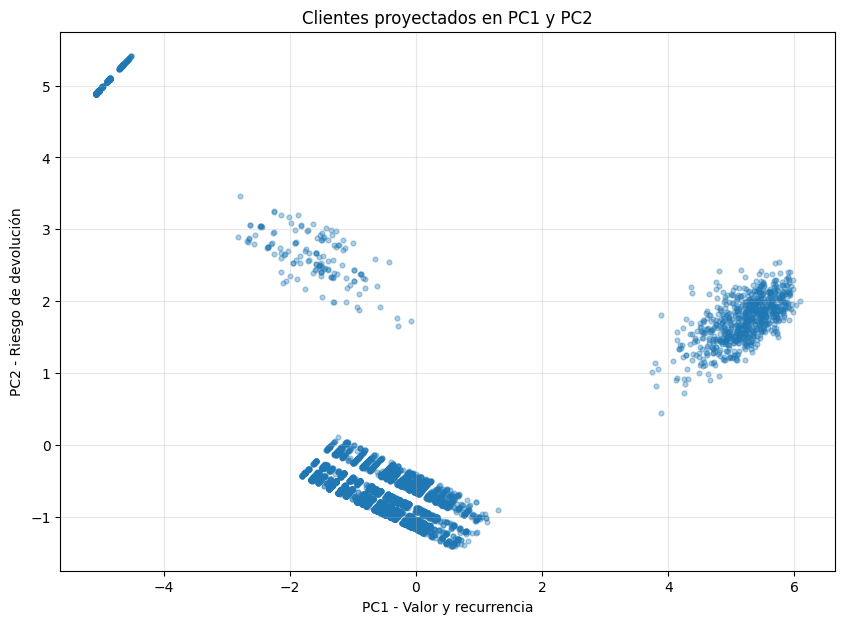

In [31]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.35,
    s=12
)

plt.xlabel("PC1 - Valor y recurrencia")
plt.ylabel("PC2 - Riesgo de devolución")
plt.title("Clientes proyectados en PC1 y PC2")
plt.grid(True, alpha=0.3)
plt.show()

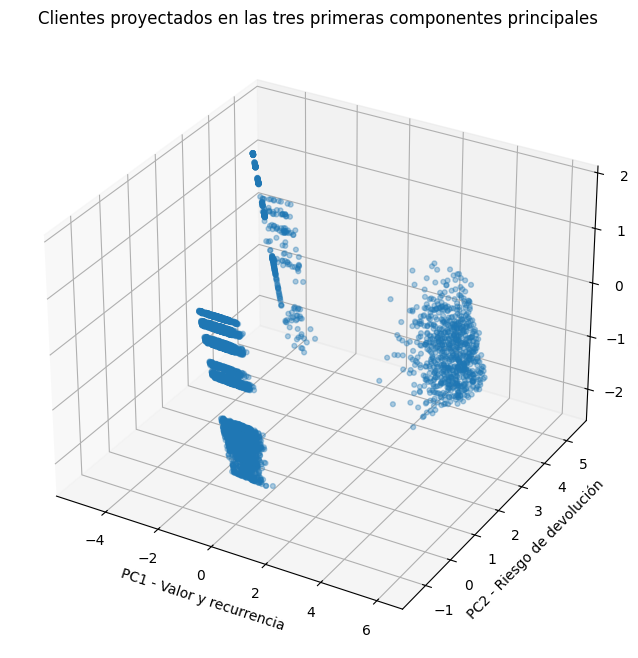

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    df_pca["PC3"],
    alpha=0.35,
    s=12
)

ax.set_xlabel("PC1 - Valor y recurrencia")
ax.set_ylabel("PC2 - Riesgo de devolución")
ax.set_zlabel("PC3 - Inactividad")
ax.set_title("Clientes proyectados en las tres primeras componentes principales")

plt.show()

### Interpretación de las componentes principales

El PCA permite resumir las variables originales en tres dimensiones principales que explican aproximadamente el 95% de la variabilidad total.

La primera componente principal se interpreta como una dimensión de **valor y recurrencia del cliente**, ya que presenta cargas elevadas en `cltv`, `net_revenue`, `frequency_orders`, `purchase_frequency`, `customer_lifetime_days` y `avg_ticket`.

La segunda componente se interpreta como una dimensión de **riesgo de devolución**, al estar dominada por `return_rate` y `returned_order_rate`.

La tercera componente se interpreta como una dimensión de **inactividad o recencia**, ya que está prácticamente explicada por `recency_days`.

Esta estructura resulta adecuada para el clustering, ya que permite segmentar clientes combinando valor económico, comportamiento de compra y riesgo operativo.

## 8. Clustering con K-Means

Una vez reducido el espacio de variables mediante PCA, se aplica K-Means sobre las tres primeras componentes principales.

El objetivo es identificar grupos de clientes con patrones similares en términos de valor económico, recurrencia, riesgo de devolución e inactividad.

Para seleccionar el número óptimo de clusters se evalúan varios valores de `k` utilizando métricas internas de clustering:

- Inercia.
- Silhouette Score.
- Davies-Bouldin Index.
- Calinski-Harabasz Index.

La elección final no se basará únicamente en las métricas, sino también en la interpretabilidad y utilidad de negocio de los segmentos obtenidos.

In [33]:
# Matriz final para clustering
cluster_features = ["PC1", "PC2", "PC3"]

X_cluster = df_pca[cluster_features].copy()

X_cluster.head()

,PC1,PC2,PC3
0,-1.373791,-0.604085,0.872384
1,-0.250955,-0.505811,-1.233808
2,-0.572525,-0.646326,-0.161841
3,-1.537003,-0.395085,0.248921
4,-1.125747,-0.565275,0.335072


In [34]:
scores = []

for k in range(3, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    scores.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster, labels)
    })

scores_df = pd.DataFrame(scores)

scores_df

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,3,8253.055293,0.758884,0.360453,14229.593229
1,4,4729.591634,0.577378,0.499333,17977.789610
2,5,3328.347418,0.597805,0.503391,19761.004091
3,6,2492.746983,0.514700,0.622049,21489.533000
4,7,2140.190524,0.481002,0.690223,21011.987951
5,8,1839.269017,0.498830,0.656534,21087.633941


- k = 3 es el mejor matemáticamente, pero demasiado simple para un análisis de negocio maduro.

- k = 5 y k = 6 son los candidatos reales.

- k = 7 y k = 8 los descartaría.

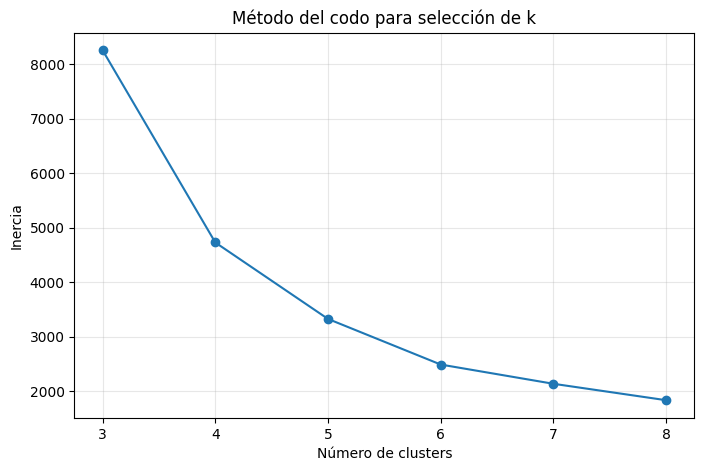

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    scores_df["k"],
    scores_df["inertia"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo para selección de k")
plt.xticks(scores_df["k"])
plt.grid(True, alpha=0.3)
plt.show()


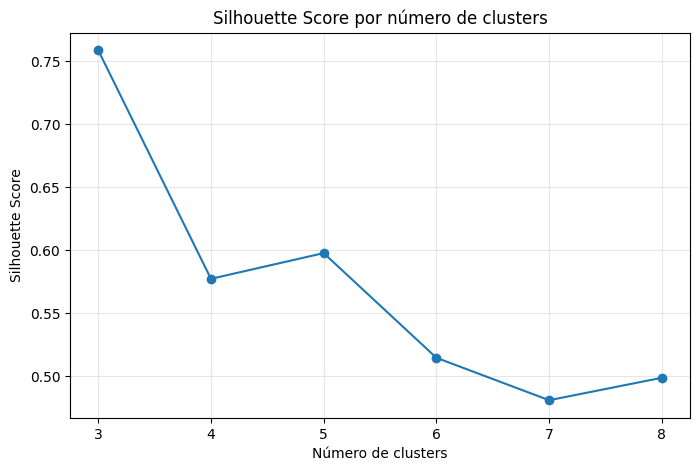

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    scores_df["k"],
    scores_df["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.xticks(scores_df["k"])
plt.grid(True, alpha=0.3)
plt.show()

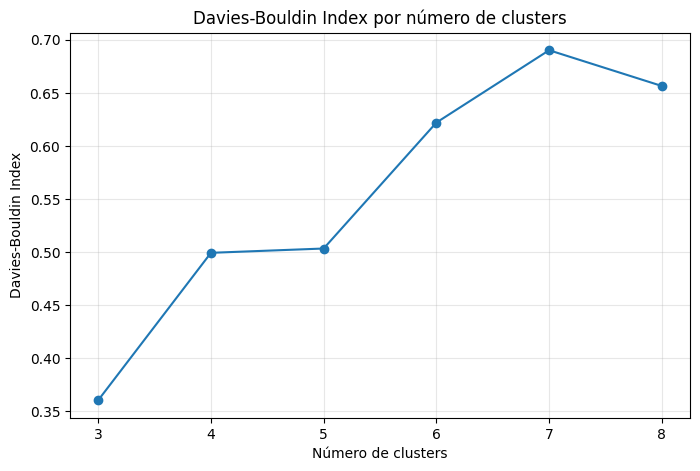

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    scores_df["k"],
    scores_df["davies_bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index por número de clusters")
plt.xticks(scores_df["k"])
plt.grid(True, alpha=0.3)
plt.show()

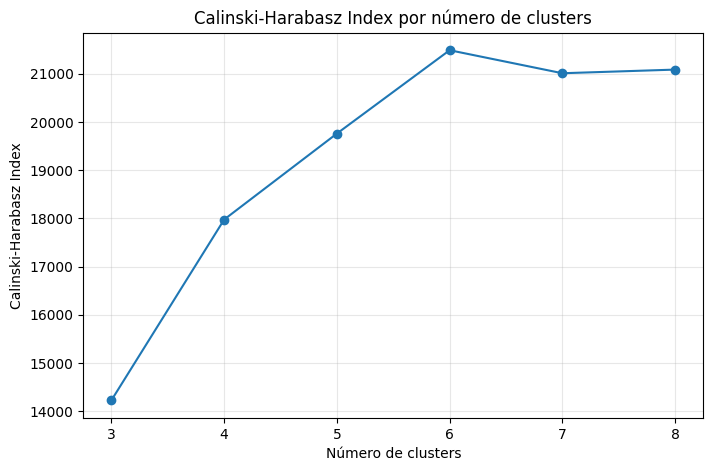

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    scores_df["k"],
    scores_df["calinski_harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Calinski-Harabasz Index")
plt.title("Calinski-Harabasz Index por número de clusters")
plt.xticks(scores_df["k"])
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
cluster_sizes = {}

for k in range(3, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    sizes = pd.Series(labels).value_counts().sort_index()
    cluster_sizes[k] = sizes

cluster_sizes_df = pd.DataFrame(cluster_sizes).fillna(0).astype(int)

cluster_sizes_df

,3,4,5,6,7,8
0,4627,1377,1359,299,1504,1216
1,750,750,750,750,750,750
2,373,367,299,1742,299,299
3,0,3256,3201,1359,741,741
4,0,0,141,141,141,141
5,0,0,0,1459,1697,633
6,0,0,0,0,618,1352
7,0,0,0,0,0,618


In [40]:
cluster_sizes_pct_df = (cluster_sizes_df / len(X_cluster) * 100).round(2)

cluster_sizes_pct_df

,3,4,5,6,7,8
0,80.47,23.95,23.63,5.20,26.16,21.15
1,13.04,13.04,13.04,13.04,13.04,13.04
2,6.49,6.38,5.20,30.30,5.20,5.20
3,0.00,56.63,55.67,23.63,12.89,12.89
4,0.00,0.00,2.45,2.45,2.45,2.45
5,0.00,0.00,0.00,25.37,29.51,11.01
6,0.00,0.00,0.00,0.00,10.75,23.51
7,0.00,0.00,0.00,0.00,0.00,10.75


Se evaluaron soluciones entre 3 y 8 clusters. Aunque la solución con 3 clusters presenta el mejor Silhouette Score y el menor índice Davies-Bouldin, fue descartada como solución final por generar una segmentación excesivamente agregada, con más del 80% de clientes concentrados en un único grupo.

Las soluciones con 5 y 6 clusters resultan las más interesantes desde una perspectiva de negocio. La solución con 5 clusters mantiene una buena calidad de separación, mientras que la solución con 6 clusters presenta el mayor índice Calinski-Harabasz y una distribución más equilibrada de clientes entre segmentos. Por este motivo, ambas soluciones se analizan en detalle antes de seleccionar la segmentación final.

## 9. Comparación de soluciones candidatas: k = 5 y k = 6

A partir de las métricas internas y del tamaño de los clusters, se seleccionan como candidatas las soluciones con 5 y 6 clusters.

La solución final se decidirá no solo por criterios estadísticos, sino también por la interpretabilidad de negocio de los segmentos resultantes.

In [41]:
def train_kmeans_and_profile(k, X_cluster, df, profile_features):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_cluster)
    
    df_temp = df.copy()
    df_temp[f"cluster_k{k}"] = labels
    
    profile = df_temp.groupby(f"cluster_k{k}").agg(
        num_customers=("customer_id", "count"),
        avg_cltv=("cltv", "mean"),
        median_cltv=("cltv", "median"),
        avg_recency_days=("recency_days", "mean"),
        median_recency_days=("recency_days", "median"),
        avg_frequency_orders=("frequency_orders", "mean"),
        median_frequency_orders=("frequency_orders", "median"),
        avg_purchase_frequency=("purchase_frequency", "mean"),
        avg_customer_lifetime_days=("customer_lifetime_days", "mean"),
        avg_ticket=("avg_ticket", "mean"),
        avg_net_revenue=("net_revenue", "mean"),
        avg_total_margin=("total_margin", "mean"),
        avg_margin_rate=("margin_rate", "mean"),
        avg_return_rate=("return_rate", "mean"),
        avg_returned_order_rate=("returned_order_rate", "mean"),
        avg_margin_impact_rate=("margin_impact_rate", "mean"),
        avg_total_returned_amount=("total_returned_amount", "mean"),
        avg_num_returns=("num_returns", "mean")
    ).reset_index()
    
    profile["customer_pct"] = (
        profile["num_customers"] / profile["num_customers"].sum() * 100
    ).round(2)
    
    return kmeans, df_temp, profile

In [42]:
# entrenaar k=5 y k=6

kmeans_5, df_k5, profile_k5 = train_kmeans_and_profile(
    5,
    X_cluster,
    df,
    profile_features
)

kmeans_6, df_k6, profile_k6 = train_kmeans_and_profile(
    6,
    X_cluster,
    df,
    profile_features
)

In [43]:
profile_k5

,cluster_k5,num_customers,avg_cltv,median_cltv,avg_recency_days,median_recency_days,avg_frequency_orders,median_frequency_orders,avg_purchase_frequency,avg_customer_lifetime_days,avg_ticket,avg_net_revenue,avg_total_margin,avg_margin_rate,avg_return_rate,avg_returned_order_rate,avg_margin_impact_rate,avg_total_returned_amount,avg_num_returns,customer_pct
0,0,1359,67.283061,51.96,107.900662,114.0,1.0,1.0,1.000000,0.000000,168.197219,168.197219,67.283061,0.400044,0.000000,0.000000,0.000000,0.000000,0.000,23.63
1,1,750,4601.904893,4559.82,158.521333,123.0,20.0,20.0,3.725759,1964.373333,574.388640,11504.152360,4601.904893,0.399997,0.024875,0.116811,0.025915,294.854240,2.432,13.04
2,2,299,0.000000,0.00,814.431438,894.0,1.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,116.390134,1.000,5.20
3,3,3201,66.337894,51.96,1086.423305,1007.0,1.0,1.0,1.000000,0.000000,165.834464,165.834464,66.337894,0.400042,0.000000,0.000000,0.000000,0.000000,0.000,55.67
4,4,141,53.019858,39.96,779.751773,895.0,1.0,1.0,1.000000,0.000000,132.540709,132.540709,53.019858,0.400045,0.478719,1.000000,0.943262,117.153830,1.000,2.45


In [44]:
profile_k6

,cluster_k6,num_customers,avg_cltv,median_cltv,avg_recency_days,median_recency_days,avg_frequency_orders,median_frequency_orders,avg_purchase_frequency,avg_customer_lifetime_days,avg_ticket,avg_net_revenue,avg_total_margin,avg_margin_rate,avg_return_rate,avg_returned_order_rate,avg_margin_impact_rate,avg_total_returned_amount,avg_num_returns,customer_pct
0,0,299,0.000000,0.00,814.431438,894.0,1.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,116.390134,1.000,5.20
1,1,750,4601.904893,4559.82,158.521333,123.0,20.0,20.0,3.725759,1964.373333,574.388640,11504.152360,4601.904893,0.399997,0.024875,0.116811,0.025915,294.854240,2.432,13.04
2,2,1742,102.040850,79.96,1119.350746,1030.5,1.0,1.0,1.000000,0.000000,255.090425,255.090425,102.040850,0.400008,0.000000,0.000000,0.000000,0.000000,0.000,30.30
3,3,1359,67.283061,51.96,107.900662,114.0,1.0,1.0,1.000000,0.000000,168.197219,168.197219,67.283061,0.400044,0.000000,0.000000,0.000000,0.000000,0.000,23.63
4,4,141,53.019858,39.96,779.751773,895.0,1.0,1.0,1.000000,0.000000,132.540709,132.540709,53.019858,0.400045,0.478719,1.000000,0.943262,117.153830,1.000,2.45
5,5,1459,23.709692,24.00,1047.108979,977.0,1.0,1.0,1.000000,0.000000,59.265661,59.265661,23.709692,0.400083,0.000000,0.000000,0.000000,0.000000,0.000,25.37


### Crear perfiles estandarizados para comparar mejor

Las medias brutas a veces son difíciles de comparar. Este heatmap nos dirá rápidamente qué caracteriza a cada cluster.

In [45]:
def create_cluster_heatmap_data(df_clustered, cluster_col, profile_features):
    cluster_means = df_clustered.groupby(cluster_col)[profile_features].mean()
    
    scaler_profile = StandardScaler()
    
    cluster_scaled = pd.DataFrame(
        scaler_profile.fit_transform(cluster_means),
        index=cluster_means.index,
        columns=cluster_means.columns
    )
    
    return cluster_scaled

In [46]:
# para k=5

heatmap_k5 = create_cluster_heatmap_data(
    df_k5,
    "cluster_k5",
    profile_features
)

heatmap_k5

,cltv,recency_days,frequency_orders,purchase_frequency,customer_lifetime_days,avg_ticket,net_revenue,total_margin,margin_rate,return_rate,returned_order_rate,margin_impact_rate,total_returned_amount,num_returns
cluster_k5,,,,,,,,,,,,,,
0,-0.488637,-1.242079,-0.5,-0.5,-0.5,-0.207052,-0.488637,-0.488637,0.500073,-0.762533,-0.895529,-0.834036,-0.978098,-0.992752
1,1.999817,-1.111499,2.0,2.0,2.0,1.895785,1.999817,1.999817,0.499783,-0.699457,-0.648441,-0.779156,1.750870,1.731044
2,-0.525560,0.580471,-0.5,-0.5,-0.5,-1.077803,-0.525560,-0.525560,-2.000000,1.773168,1.219750,1.283692,0.099129,0.127230
3,-0.489156,1.282095,-0.5,-0.5,-0.5,-0.219284,-0.489156,-0.489156,0.500061,-0.762533,-0.895529,-0.834036,-0.978098,-0.992752
4,-0.496464,0.491012,-0.5,-0.5,-0.5,-0.391645,-0.496465,-0.496464,0.500083,0.451355,1.219750,1.163537,0.106197,0.127230


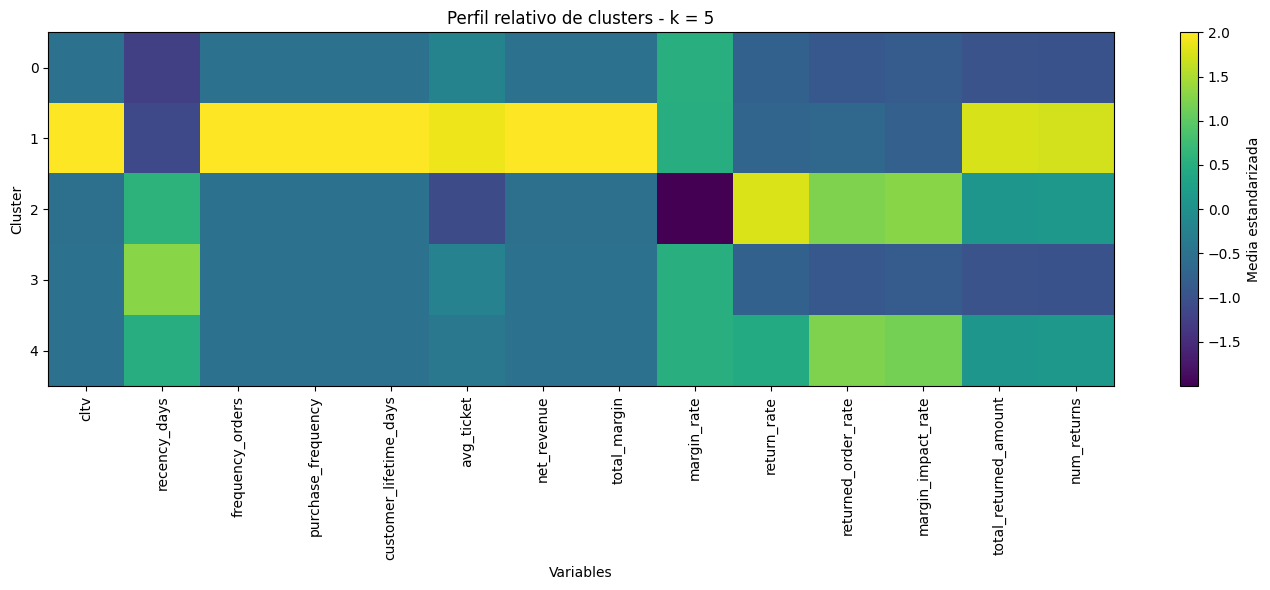

In [47]:
plt.figure(figsize=(14, 6))

plt.imshow(heatmap_k5, aspect="auto")
plt.colorbar(label="Media estandarizada")

plt.xticks(
    ticks=range(len(heatmap_k5.columns)),
    labels=heatmap_k5.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(heatmap_k5.index)),
    labels=heatmap_k5.index
)

plt.title("Perfil relativo de clusters - k = 5")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [48]:
# para k=6

heatmap_k6 = create_cluster_heatmap_data(
    df_k6,
    "cluster_k6",
    profile_features
)

heatmap_k6

,cltv,recency_days,frequency_orders,purchase_frequency,customer_lifetime_days,avg_ticket,net_revenue,total_margin,margin_rate,return_rate,returned_order_rate,margin_impact_rate,total_returned_amount,num_returns
cluster_k6,,,,,,,,,,,,,,
0,-0.476132,0.359148,-0.447214,-0.447214,-0.447214,-1.063348,-0.476132,-0.476132,-2.236068,1.987548,1.408490,1.475311,0.266690,0.297147
1,2.235666,-1.285266,2.236068,2.236068,2.236068,2.017530,2.235666,2.235666,0.446959,-0.598660,-0.513583,-0.663824,1.947069,1.925392
2,-0.416002,1.123603,-0.447214,-0.447214,-0.447214,0.304893,-0.416001,-0.416002,0.447028,-0.664634,-0.767799,-0.720733,-0.829214,-0.839895
3,-0.436484,-1.412176,-0.447214,-0.447214,-0.447214,-0.161180,-0.436484,-0.436484,0.447270,-0.664634,-0.767799,-0.720733,-0.829214,-0.839895
4,-0.444889,0.272204,-0.447214,-0.447214,-0.447214,-0.352433,-0.444889,-0.444889,0.447281,0.605016,1.408490,1.350713,0.273881,0.297147
5,-0.462160,0.942488,-0.447214,-0.447214,-0.447214,-0.745462,-0.462161,-0.462160,0.447530,-0.664634,-0.767799,-0.720733,-0.829214,-0.839895


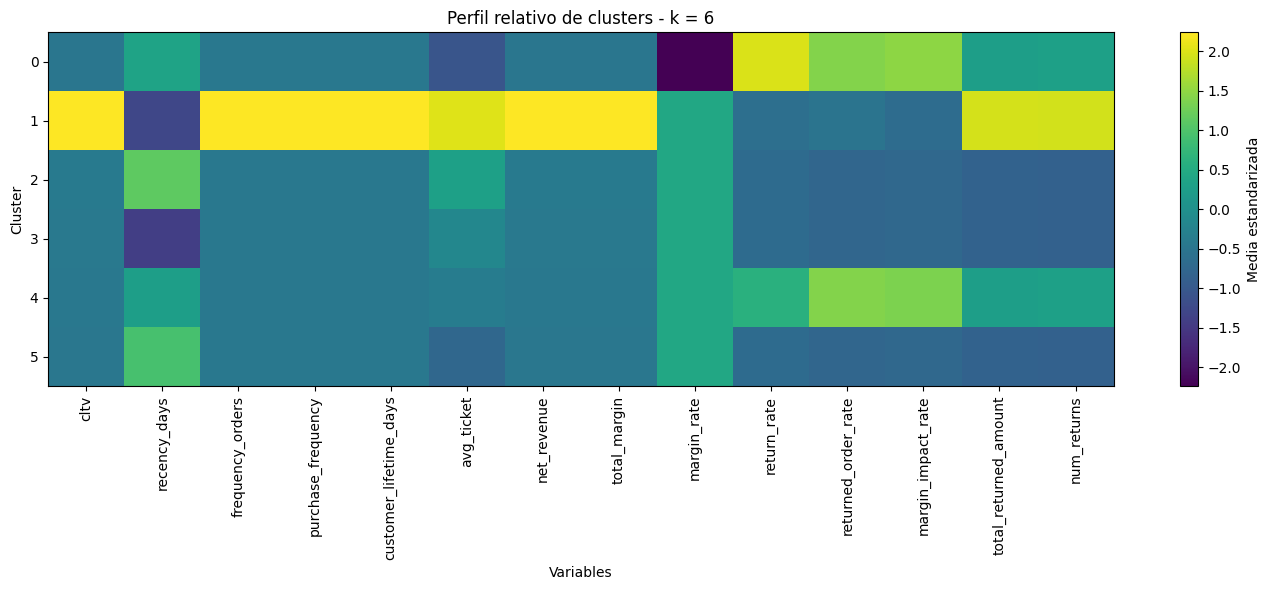

In [49]:
plt.figure(figsize=(14, 6))

plt.imshow(heatmap_k6, aspect="auto")
plt.colorbar(label="Media estandarizada")

plt.xticks(
    ticks=range(len(heatmap_k6.columns)),
    labels=heatmap_k6.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(heatmap_k6.index)),
    labels=heatmap_k6.index
)

plt.title("Perfil relativo de clusters - k = 6")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


Aunque la solución con 5 clusters presenta una separación ligeramente superior en algunas métricas, la solución con 6 clusters ofrece una segmentación más accionable desde el punto de vista de negocio. En particular, permite dividir el gran grupo de clientes inactivos en dos segmentos diferenciados según su ticket y valor económico, lo que facilita diseñar estrategias comerciales distintas para clientes dormidos con potencial y clientes de baja prioridad.

Tras comparar las soluciones candidatas de 5 y 6 clusters, se selecciona finalmente la solución con 6 clusters. Aunque la segmentación con 5 clusters presenta una buena calidad estadística, mantiene un grupo demasiado amplio de clientes inactivos, que concentra más de la mitad de la base de clientes.

La solución con 6 clusters permite dividir ese bloque en dos segmentos diferenciados: clientes dormidos de ticket medio y clientes dormidos de bajo ticket. Esta separación aporta mayor utilidad de negocio, ya que permite priorizar acciones de reactivación sobre clientes con mayor potencial económico y reducir inversión en segmentos de baja rentabilidad esperada.

Por tanto, la elección final de k = 6 responde no solo a criterios estadísticos, sino también a la interpretabilidad y aplicabilidad comercial de los segmentos obtenidos.

| Cluster | Nombre del segmento | Nº clientes | % clientes | Perfil principal | Métricas clave | Acción recomendada |
|---:|---|---:|---:|---|---|---|
| 0 | Clientes con devolución total | 299 | 5,20% | Clientes cuyo valor neto queda prácticamente anulado por devoluciones. Presentan CLTV y revenue neto igual a 0, con tasa de devolución máxima. | CLTV medio: 0,00 · Recency media: 814 días · Return rate: 1,00 · Returned order rate: 1,00 · Margin impact rate: 1,00 | Analizar causas de devolución, revisar productos asociados y evitar campañas comerciales agresivas sobre este segmento. |
| 1 | Clientes premium recurrentes | 750 | 13,04% | Clientes de mayor valor económico, alta recurrencia y elevada rentabilidad. Son el segmento prioritario del negocio. | CLTV medio: 4.601,90 · Frecuencia media: 20 pedidos · Net revenue medio: 11.504,15 · Return rate: 0,025 | Fidelización premium, beneficios exclusivos, campañas personalizadas y acciones de retención. |
| 2 | Clientes dormidos de ticket medio | 1.742 | 30,30% | Clientes inactivos desde hace mucho tiempo, con una única compra, pero con ticket medio razonable. Pueden tener potencial de reactivación. | CLTV medio: 102,04 · Recency media: 1.119 días · Frecuencia: 1 pedido · Ticket medio: 255,09 · Return rate: 0,00 | Campañas de reactivación selectiva, recordatorio de marca y ofertas de retorno. |
| 3 | Clientes recientes de bajo valor | 1.359 | 23,63% | Clientes que han comprado hace relativamente poco, sin devoluciones, pero todavía con bajo valor y sin recurrencia. | CLTV medio: 67,28 · Recency media: 108 días · Frecuencia: 1 pedido · Ticket medio: 168,20 · Return rate: 0,00 | Campañas de segunda compra, recomendaciones personalizadas y acciones para convertirlos en recurrentes. |
| 4 | Clientes con alta devolución parcial | 141 | 2,45% | Clientes de bajo valor con alta tasa de devolución. No anulan totalmente el valor, pero deterioran mucho la rentabilidad. | CLTV medio: 53,02 · Recency media: 780 días · Return rate: 0,479 · Returned order rate: 1,00 · Margin impact rate: 0,943 | Revisar motivos de devolución, analizar productos comprados y limitar incentivos promocionales. |
| 5 | Clientes dormidos de bajo ticket | 1.459 | 25,37% | Clientes inactivos, de una sola compra y bajo importe. Tienen baja prioridad comercial por su escaso valor histórico. | CLTV medio: 23,71 · Recency media: 1.047 días · Frecuencia: 1 pedido · Ticket medio: 59,27 · Return rate: 0,00 | Campañas automatizadas de bajo coste y baja inversión comercial directa. |

## 10. Modelo final de clustering con k = 6

Tras comparar distintas soluciones de clustering, se selecciona finalmente una segmentación con 6 clusters.

La elección de `k = 6` se justifica porque permite obtener segmentos más accionables desde el punto de vista de negocio. En particular, separa mejor los clientes inactivos en dos grupos diferenciados según su valor económico: clientes dormidos de ticket medio y clientes dormidos de bajo ticket.

El modelo final se entrena sobre las tres primeras componentes principales:

- **PC1:** valor y recurrencia del cliente.
- **PC2:** riesgo de devolución.
- **PC3:** inactividad o recencia.

In [50]:
# Entrenamiento final de K-Means con k = 6
K_FINAL = 6

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=50
)

df_pca["cluster_final"] = kmeans_final.fit_predict(X_cluster)

df_pca.head()

,PC1,PC2,PC3,customer_id,cluster_final
0,-1.373791,-0.604085,0.872384,5642,5
1,-0.250955,-0.505811,-1.233808,2448,3
2,-0.572525,-0.646326,-0.161841,5665,5
3,-1.537003,-0.395085,0.248921,5742,5
4,-1.125747,-0.565275,0.335072,5743,5


In [51]:
df_final = df.copy()

df_final["cluster_final"] = df_pca["cluster_final"].values

df_final[["customer_id", "cluster_final"]].head()

,customer_id,cluster_final
0,5642,5
1,2448,3
2,5665,5
3,5742,5
4,5743,5


In [52]:
cluster_counts = (
    df_final["cluster_final"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["cluster_final", "num_customers"]

cluster_counts["customer_pct"] = (
    cluster_counts["num_customers"] / cluster_counts["num_customers"].sum() * 100
).round(2)

cluster_counts

,cluster_final,num_customers,customer_pct
0,0,299,5.20
1,1,750,13.04
2,2,1742,30.30
3,3,1359,23.63
4,4,141,2.45
5,5,1459,25.37


In [53]:
cluster_names = {
    0: "Clientes con devolución total",
    1: "Clientes premium recurrentes",
    2: "Clientes dormidos de ticket medio",
    3: "Clientes recientes de bajo valor",
    4: "Clientes con alta devolución parcial",
    5: "Clientes dormidos de bajo ticket"
}

df_final["cluster_name"] = df_final["cluster_final"].map(cluster_names)

df_final[["customer_id", "cluster_final", "cluster_name"]].head()

,customer_id,cluster_final,cluster_name
0,5642,5,Clientes dormidos de bajo ticket
1,2448,3,Clientes recientes de bajo valor
2,5665,5,Clientes dormidos de bajo ticket
3,5742,5,Clientes dormidos de bajo ticket
4,5743,5,Clientes dormidos de bajo ticket


In [54]:
df_final["cluster_name"].isnull().sum()

np.int64(0)

In [55]:
df_final["cluster_name"].value_counts()

cluster_name
Clientes dormidos de ticket medio       1742
Clientes dormidos de bajo ticket        1459
Clientes recientes de bajo valor        1359
Clientes premium recurrentes             750
Clientes con devolución total            299
Clientes con alta devolución parcial     141
Name: count, dtype: int64

In [56]:
df_pca["cluster_name"] = df_pca["cluster_final"].map(cluster_names)

df_pca.head()

,PC1,PC2,PC3,customer_id,cluster_final,cluster_name
0,-1.373791,-0.604085,0.872384,5642,5,Clientes dormidos de bajo ticket
1,-0.250955,-0.505811,-1.233808,2448,3,Clientes recientes de bajo valor
2,-0.572525,-0.646326,-0.161841,5665,5,Clientes dormidos de bajo ticket
3,-1.537003,-0.395085,0.248921,5742,5,Clientes dormidos de bajo ticket
4,-1.125747,-0.565275,0.335072,5743,5,Clientes dormidos de bajo ticket


In [57]:
final_labels = df_final["cluster_final"]

final_silhouette = silhouette_score(X_cluster, final_labels)
final_davies_bouldin = davies_bouldin_score(X_cluster, final_labels)
final_calinski_harabasz = calinski_harabasz_score(X_cluster, final_labels)
final_inertia = kmeans_final.inertia_

final_metrics = pd.DataFrame({
    "metric": [
        "inertia",
        "silhouette_score",
        "davies_bouldin_index",
        "calinski_harabasz_index"
    ],
    "value": [
        final_inertia,
        final_silhouette,
        final_davies_bouldin,
        final_calinski_harabasz
    ]
})

final_metrics

,metric,value
0,inertia,2492.746983
1,silhouette_score,0.514700
2,davies_bouldin_index,0.622049
3,calinski_harabasz_index,21489.533000


La segmentación final se ha entrenado con `k = 6` clusters sobre las tres primeras componentes principales del PCA.

Aunque soluciones con menor número de clusters presentaban mejores métricas de separación en algunos indicadores, la solución de 6 clusters ofrece mayor utilidad de negocio al diferenciar mejor los perfiles de clientes inactivos, clientes recurrentes de alto valor y clientes con riesgo asociado a devoluciones.

Esta segmentación permite pasar de una visión puramente descriptiva del cliente a una clasificación accionable, útil para diseñar estrategias comerciales diferenciadas.

### Evaluación del modelo final

El modelo final de K-Means se entrena con `k = 6` clusters utilizando las tres primeras componentes principales del PCA. Estas componentes recogen aproximadamente el 95% de la variabilidad total del conjunto de variables original.

La solución final obtiene un Silhouette Score de 0,515, lo que indica una separación razonable entre segmentos para un problema real de comportamiento de clientes. Además, presenta el mayor índice Calinski-Harabasz entre las alternativas evaluadas, lo que refuerza la calidad global de la partición.

Aunque soluciones con menor número de clusters presentaban mejores valores en algunas métricas, la segmentación con 6 clusters ofrece una mayor utilidad de negocio, al diferenciar perfiles de clientes recurrentes, recientes, dormidos y clientes con riesgo por devolución.

## 11. Visualización de los clusters finales

Se visualizan los segmentos obtenidos en el espacio PCA. La primera representación utiliza las dos primeras componentes principales:

- **PC1:** valor y recurrencia del cliente.
- **PC2:** riesgo de devolución.

Posteriormente, se genera una visualización 3D incorporando también la tercera componente:

- **PC3:** inactividad o recencia.

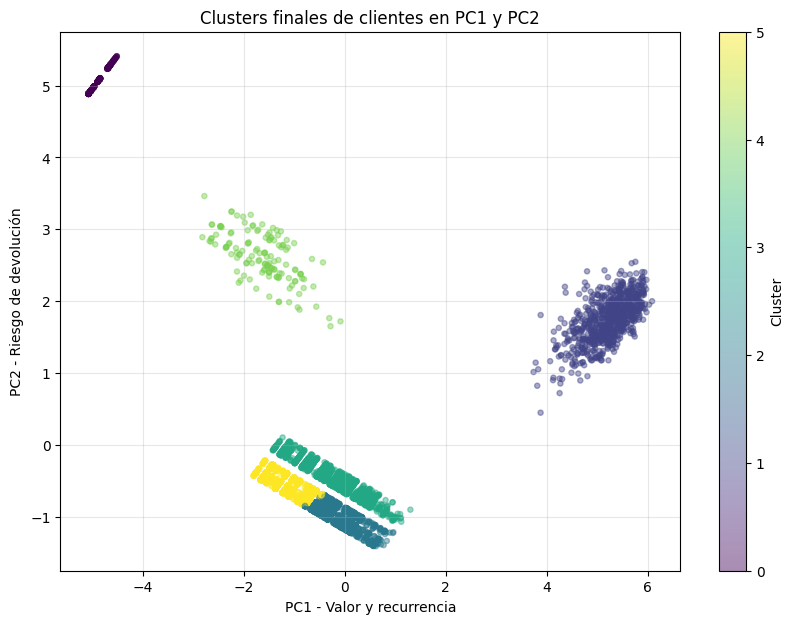

In [58]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["cluster_final"],
    alpha=0.45,
    s=14
)

plt.xlabel("PC1 - Valor y recurrencia")
plt.ylabel("PC2 - Riesgo de devolución")
plt.title("Clusters finales de clientes en PC1 y PC2")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.show()

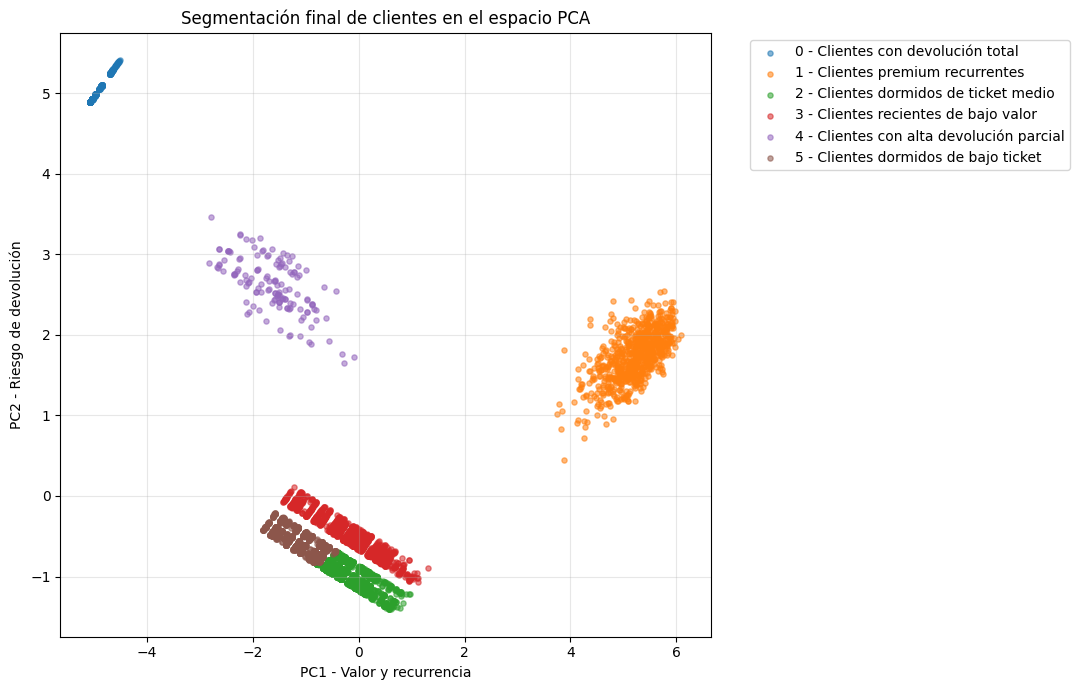

In [59]:
plt.figure(figsize=(11, 7))

for cluster_id, cluster_name in cluster_names.items():
    subset = df_pca[df_pca["cluster_final"] == cluster_id]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.55,
        s=14,
        label=f"{cluster_id} - {cluster_name}"
    )

plt.xlabel("PC1 - Valor y recurrencia")
plt.ylabel("PC2 - Riesgo de devolución")
plt.title("Segmentación final de clientes en el espacio PCA")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

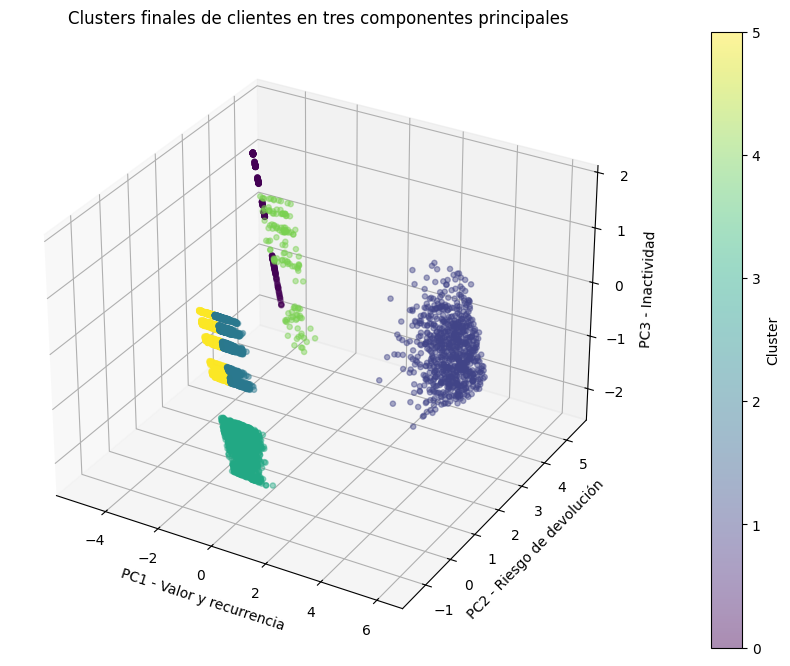

In [60]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    df_pca["PC3"],
    c=df_pca["cluster_final"],
    alpha=0.45,
    s=14
)

ax.set_xlabel("PC1 - Valor y recurrencia")
ax.set_ylabel("PC2 - Riesgo de devolución")
ax.set_zlabel("PC3 - Inactividad")
ax.set_title("Clusters finales de clientes en tres componentes principales")

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Cluster")

plt.show()

In [61]:
cluster_profile_final = df_final.groupby(["cluster_final", "cluster_name"]).agg(
    num_customers=("customer_id", "count"),
    avg_cltv=("cltv", "mean"),
    median_cltv=("cltv", "median"),
    avg_recency_days=("recency_days", "mean"),
    median_recency_days=("recency_days", "median"),
    avg_frequency_orders=("frequency_orders", "mean"),
    median_frequency_orders=("frequency_orders", "median"),
    avg_purchase_frequency=("purchase_frequency", "mean"),
    avg_customer_lifetime_days=("customer_lifetime_days", "mean"),
    avg_ticket=("avg_ticket", "mean"),
    avg_net_revenue=("net_revenue", "mean"),
    avg_total_margin=("total_margin", "mean"),
    avg_margin_rate=("margin_rate", "mean"),
    avg_return_rate=("return_rate", "mean"),
    avg_returned_order_rate=("returned_order_rate", "mean"),
    avg_margin_impact_rate=("margin_impact_rate", "mean"),
    avg_total_returned_amount=("total_returned_amount", "mean"),
    avg_num_returns=("num_returns", "mean")
).reset_index()

cluster_profile_final["customer_pct"] = (
    cluster_profile_final["num_customers"] / cluster_profile_final["num_customers"].sum() * 100
).round(2)

cluster_profile_final

,cluster_final,cluster_name,num_customers,avg_cltv,median_cltv,avg_recency_days,median_recency_days,avg_frequency_orders,median_frequency_orders,avg_purchase_frequency,...,avg_ticket,avg_net_revenue,avg_total_margin,avg_margin_rate,avg_return_rate,avg_returned_order_rate,avg_margin_impact_rate,avg_total_returned_amount,avg_num_returns,customer_pct
0,0,Clientes con devolución total,299,0.000000,0.00,814.431438,894.0,1.0,1.0,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,116.390134,1.000,5.20
1,1,Clientes premium recurrentes,750,4601.904893,4559.82,158.521333,123.0,20.0,20.0,3.725759,...,574.388640,11504.152360,4601.904893,0.399997,0.024875,0.116811,0.025915,294.854240,2.432,13.04
2,2,Clientes dormidos de ticket medio,1742,102.040850,79.96,1119.350746,1030.5,1.0,1.0,1.000000,...,255.090425,255.090425,102.040850,0.400008,0.000000,0.000000,0.000000,0.000000,0.000,30.30
3,3,Clientes recientes de bajo valor,1359,67.283061,51.96,107.900662,114.0,1.0,1.0,1.000000,...,168.197219,168.197219,67.283061,0.400044,0.000000,0.000000,0.000000,0.000000,0.000,23.63
4,4,Clientes con alta devolución parcial,141,53.019858,39.96,779.751773,895.0,1.0,1.0,1.000000,...,132.540709,132.540709,53.019858,0.400045,0.478719,1.000000,0.943262,117.153830,1.000,2.45
5,5,Clientes dormidos de bajo ticket,1459,23.709692,24.00,1047.108979,977.0,1.0,1.0,1.000000,...,59.265661,59.265661,23.709692,0.400083,0.000000,0.000000,0.000000,0.000000,0.000,25.37


In [62]:
cluster_profile_final_rounded = cluster_profile_final.copy()

numeric_cols = cluster_profile_final_rounded.select_dtypes(include=["number"]).columns

cluster_profile_final_rounded[numeric_cols] = cluster_profile_final_rounded[numeric_cols].round(2)

cluster_profile_final_rounded

,cluster_final,cluster_name,num_customers,avg_cltv,median_cltv,avg_recency_days,median_recency_days,avg_frequency_orders,median_frequency_orders,avg_purchase_frequency,...,avg_ticket,avg_net_revenue,avg_total_margin,avg_margin_rate,avg_return_rate,avg_returned_order_rate,avg_margin_impact_rate,avg_total_returned_amount,avg_num_returns,customer_pct
0,0,Clientes con devolución total,299,0.00,0.00,814.43,894.0,1.0,1.0,1.00,...,0.00,0.00,0.00,0.0,1.00,1.00,1.00,116.39,1.00,5.20
1,1,Clientes premium recurrentes,750,4601.90,4559.82,158.52,123.0,20.0,20.0,3.73,...,574.39,11504.15,4601.90,0.4,0.02,0.12,0.03,294.85,2.43,13.04
2,2,Clientes dormidos de ticket medio,1742,102.04,79.96,1119.35,1030.5,1.0,1.0,1.00,...,255.09,255.09,102.04,0.4,0.00,0.00,0.00,0.00,0.00,30.30
3,3,Clientes recientes de bajo valor,1359,67.28,51.96,107.90,114.0,1.0,1.0,1.00,...,168.20,168.20,67.28,0.4,0.00,0.00,0.00,0.00,0.00,23.63
4,4,Clientes con alta devolución parcial,141,53.02,39.96,779.75,895.0,1.0,1.0,1.00,...,132.54,132.54,53.02,0.4,0.48,1.00,0.94,117.15,1.00,2.45
5,5,Clientes dormidos de bajo ticket,1459,23.71,24.00,1047.11,977.0,1.0,1.0,1.00,...,59.27,59.27,23.71,0.4,0.00,0.00,0.00,0.00,0.00,25.37


In [66]:
import plotly.graph_objects as go
import plotly.io as pio

# Abrir la gráfica en el navegador para que el zoom y el giro funcionen mejor
pio.renderers.default = "browser"

In [69]:
import plotly.graph_objects as go
import plotly.io as pio

# Para abrirla en navegador y que el zoom vaya mejor
pio.renderers.default = "browser"

fig = go.Figure()

for cluster_id, cluster_name in cluster_names.items():
    subset = df_pca[df_pca["cluster_final"] == cluster_id]

    fig.add_trace(
        go.Scatter3d(
            x=subset["PC1"],
            y=subset["PC2"],
            z=subset["PC3"],
            mode="markers",
            name=f"{cluster_id} - {cluster_name}",
            marker=dict(
                size=4,
                opacity=0.70
            ),
            text=subset["customer_id"],
            hovertemplate=(
                "<b>Cliente:</b> %{text}<br>"
                "<b>PC1 - Valor y recurrencia:</b> %{x:.2f}<br>"
                "<b>PC2 - Riesgo de devolución:</b> %{y:.2f}<br>"
                "<b>PC3 - Inactividad:</b> %{z:.2f}<br>"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Clusters finales de clientes en tres componentes principales",
    width=1300,
    height=900,
    paper_bgcolor="white",
    scene=dict(
        xaxis=dict(
            title="PC1 - Valor y recurrencia",
            showgrid=True,
            gridcolor="lightgray",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="gray",
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2
        ),
        yaxis=dict(
            title="PC2 - Riesgo de devolución",
            showgrid=True,
            gridcolor="lightgray",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="gray",
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2
        ),
        zaxis=dict(
            title="PC3 - Inactividad",
            showgrid=True,
            gridcolor="lightgray",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="gray",
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2
        ),
        aspectmode="cube",
        camera=dict(
            eye=dict(x=1.7, y=1.7, z=1.2)
        )
    ),
    legend=dict(
        title="Segmento",
        x=1.02,
        y=1
    ),
    margin=dict(l=0, r=0, b=0, t=60)
)

fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "modeBarButtonsToRemove": ["select3d", "lasso3d"]
    }
)

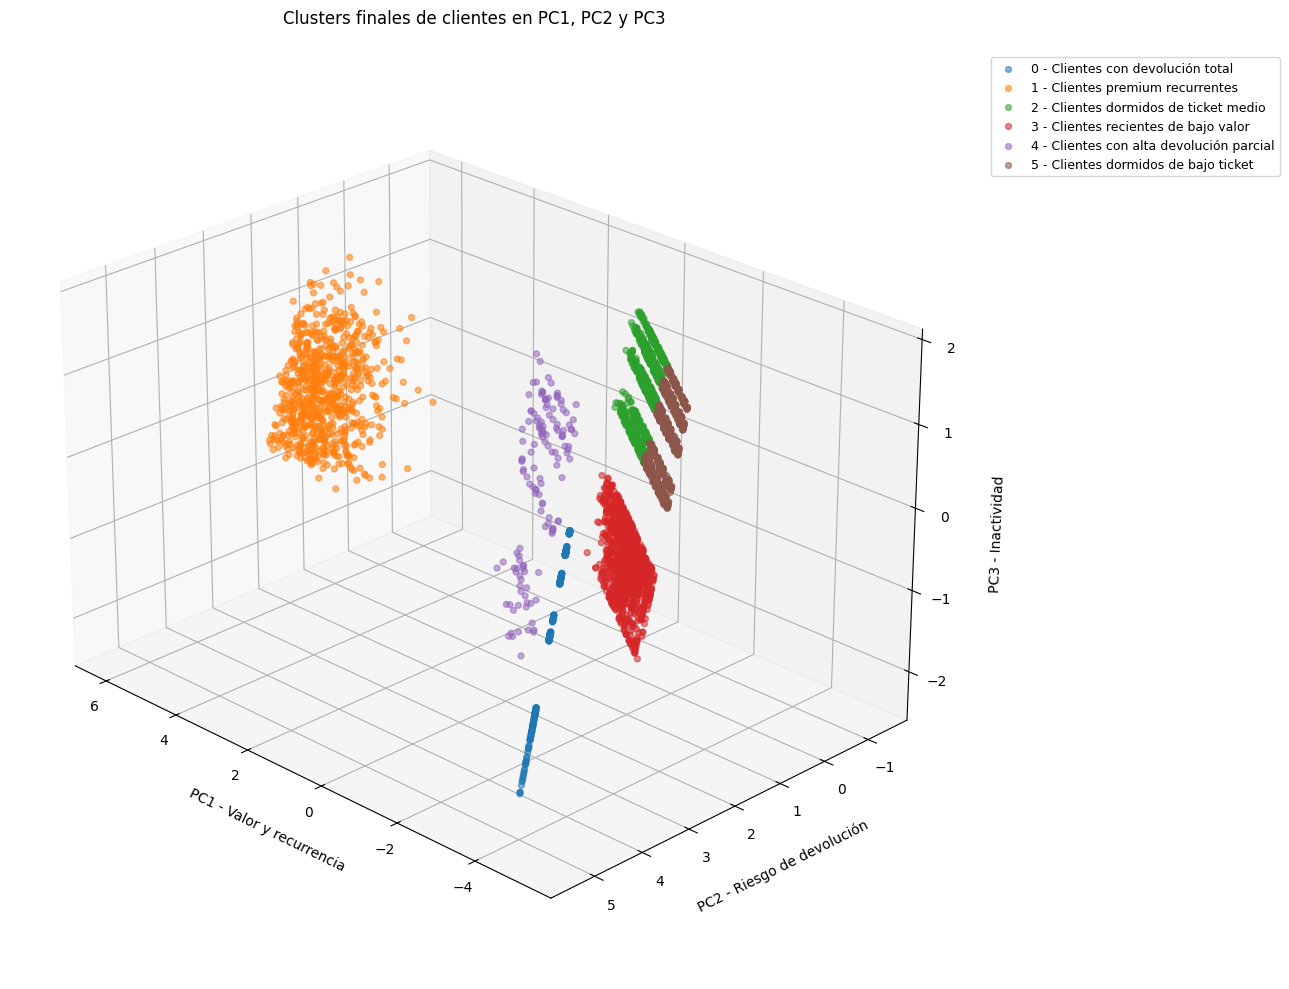

In [64]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

for cluster_id, cluster_name in cluster_names.items():
    subset = df_pca[df_pca["cluster_final"] == cluster_id]
    
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        s=18,
        alpha=0.55,
        label=f"{cluster_id} - {cluster_name}"
    )

ax.set_xlabel("PC1 - Valor y recurrencia", labelpad=12)
ax.set_ylabel("PC2 - Riesgo de devolución", labelpad=12)
ax.set_zlabel("PC3 - Inactividad", labelpad=12)

ax.set_title("Clusters finales de clientes en PC1, PC2 y PC3", pad=20)

# Cambiar el ángulo de visión
ax.view_init(elev=25, azim=135)

# Hacer la caja 3D más amplia
ax.set_box_aspect((1.6, 1.2, 1.0))

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

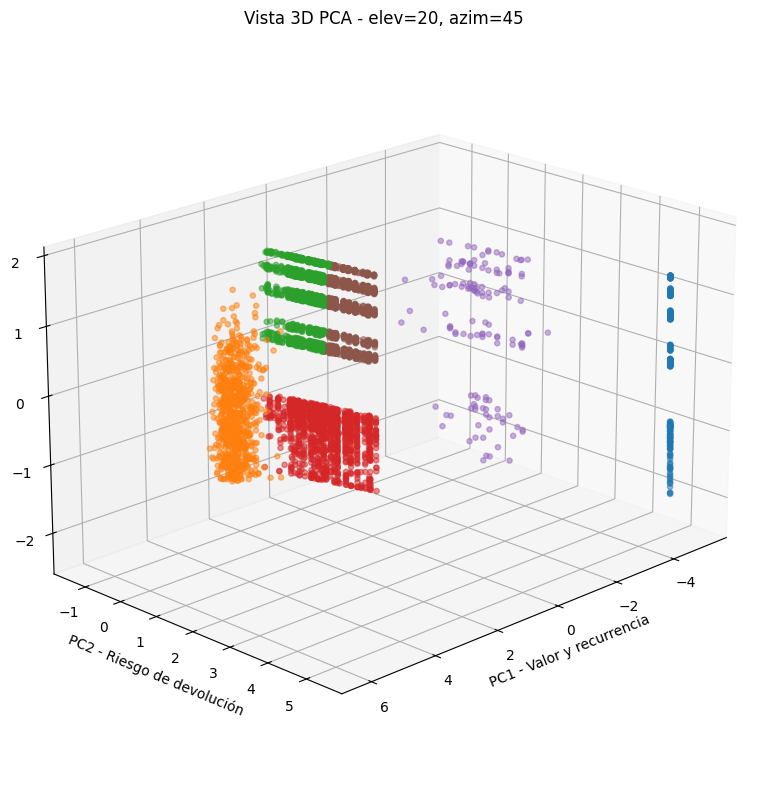

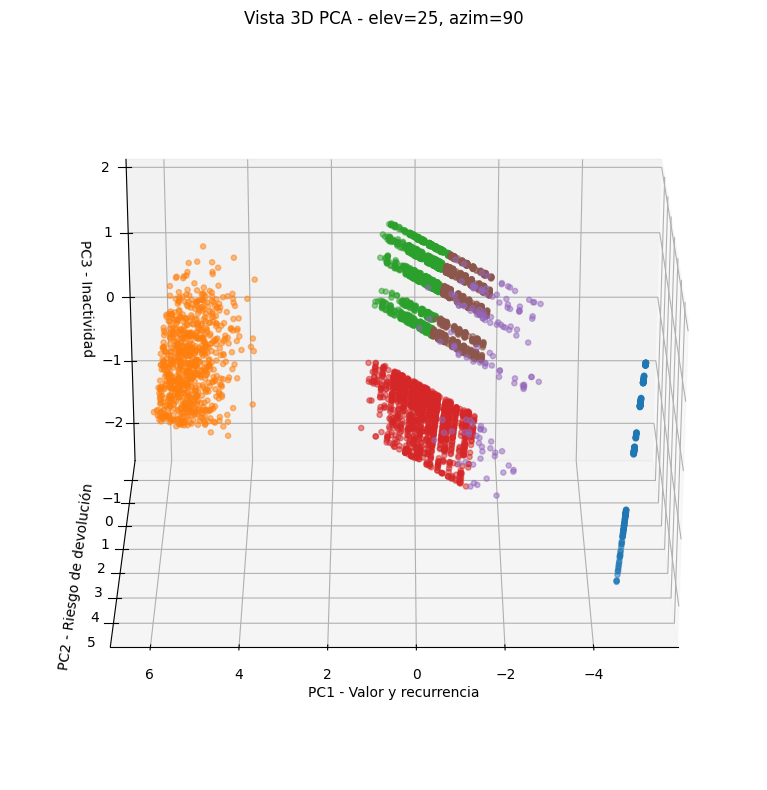

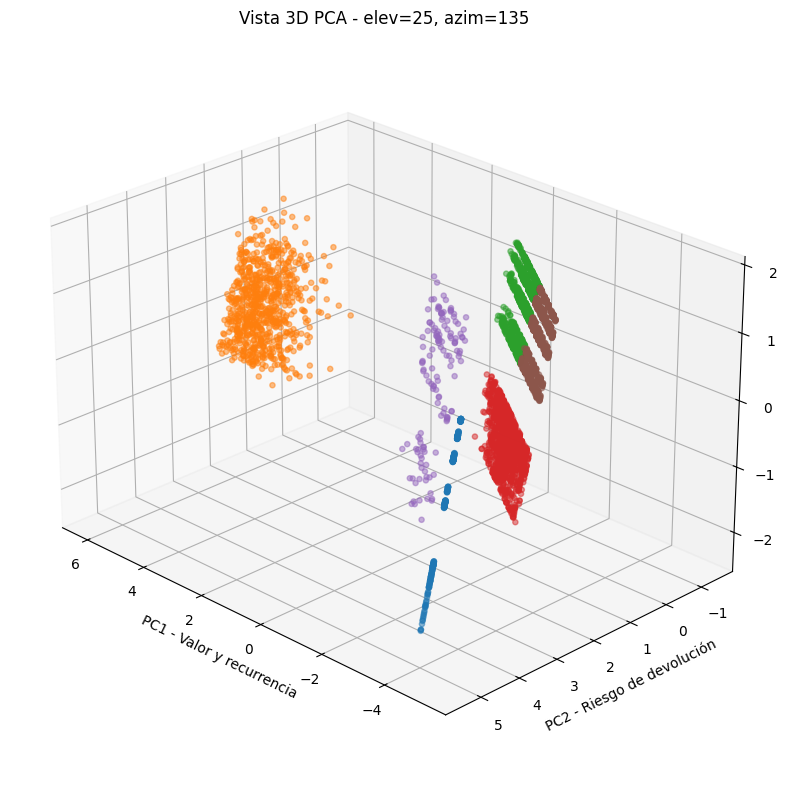

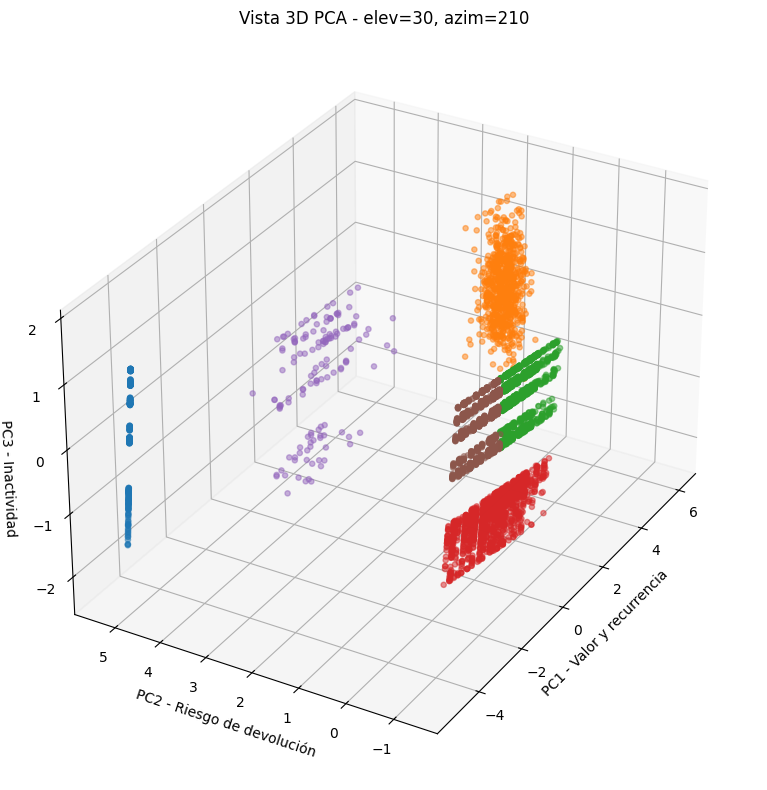

In [65]:
angles = [
    (20, 45),
    (25, 90),
    (25, 135),
    (30, 210)
]

for elev, azim in angles:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    
    for cluster_id, cluster_name in cluster_names.items():
        subset = df_pca[df_pca["cluster_final"] == cluster_id]
        
        ax.scatter(
            subset["PC1"],
            subset["PC2"],
            subset["PC3"],
            s=14,
            alpha=0.5,
            label=f"{cluster_id} - {cluster_name}"
        )
    
    ax.set_xlabel("PC1 - Valor y recurrencia")
    ax.set_ylabel("PC2 - Riesgo de devolución")
    ax.set_zlabel("PC3 - Inactividad")
    
    ax.set_title(f"Vista 3D PCA - elev={elev}, azim={azim}")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1.6, 1.2, 1.0))
    
    plt.tight_layout()
    plt.show()

### Interpretación de la segmentación final

La visualización de los clusters en el espacio PCA muestra una separación clara entre los principales perfiles de clientes.

La primera componente principal, asociada al valor y la recurrencia, permite identificar claramente el segmento de clientes premium recurrentes, situado en la zona de mayor PC1. Este grupo concentra los clientes con mayor CLTV, mayor frecuencia de compra y mayor revenue neto.

La segunda componente, asociada al riesgo de devolución, separa los clientes con devolución total y los clientes con alta devolución parcial. Estos segmentos presentan bajo valor económico y un impacto elevado de las devoluciones sobre la rentabilidad.

La tercera componente, asociada a la inactividad, permite diferenciar dentro de los clientes no recurrentes entre clientes recientes y clientes dormidos. Esta separación es especialmente relevante desde el punto de vista de negocio, ya que permite distinguir clientes con potencial de segunda compra frente a clientes inactivos desde hace mucho tiempo.

En conjunto, la segmentación final permite clasificar la cartera de clientes en seis perfiles accionables: clientes premium, clientes recientes, clientes dormidos de ticket medio, clientes dormidos de bajo ticket, clientes con devolución total y clientes con alta devolución parcial.

### Visualización 3D final de los segmentos de clientes

Se representa la segmentación final de clientes en el espacio formado por las tres primeras componentes principales utilizadas en el clustering:

- **PC1:** valor y recurrencia del cliente.
- **PC2:** riesgo de devolución.
- **PC3:** inactividad o recencia.

Esta visualización permite observar de forma interactiva la separación entre los seis segmentos finales.

In [70]:
import plotly.graph_objects as go
import plotly.io as pio

# Abrir la visualización en navegador para mejorar zoom, giro e interacción
pio.renderers.default = "browser"

# Paleta manual para que los segmentos se distingan mejor
cluster_colors = {
    0: "#E74C3C",  # rojo - devolución total
    1: "#2E86C1",  # azul - premium
    2: "#F4D03F",  # amarillo - dormidos ticket medio
    3: "#58D68D",  # verde - recientes bajo valor
    4: "#8E44AD",  # morado - alta devolución parcial
    5: "#F39C12"   # naranja - dormidos bajo ticket
}

fig = go.Figure()

for cluster_id, cluster_name in cluster_names.items():
    subset = df_pca[df_pca["cluster_final"] == cluster_id]

    fig.add_trace(
        go.Scatter3d(
            x=subset["PC1"],
            y=subset["PC2"],
            z=subset["PC3"],
            mode="markers",
            name=f"{cluster_id} - {cluster_name}",
            marker=dict(
                size=4,
                opacity=0.72,
                color=cluster_colors[cluster_id],
                line=dict(
                    width=0.2,
                    color="rgba(50,50,50,0.35)"
                )
            ),
            text=subset["customer_id"],
            hovertemplate=(
                "<b>Cliente:</b> %{text}<br>"
                "<b>Segmento:</b> " + cluster_name + "<br>"
                "<b>PC1 - Valor y recurrencia:</b> %{x:.2f}<br>"
                "<b>PC2 - Riesgo de devolución:</b> %{y:.2f}<br>"
                "<b>PC3 - Inactividad:</b> %{z:.2f}<br>"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title=dict(
        text="Segmentación final de clientes en el espacio PCA 3D",
        x=0.5,
        xanchor="center",
        font=dict(
            size=22,
            family="Arial"
        )
    ),
    width=1450,
    height=950,
    paper_bgcolor="white",
    scene=dict(
        xaxis=dict(
            title=dict(
                text="PC1 - Valor y recurrencia",
                font=dict(size=13)
            ),
            showgrid=True,
            gridcolor="rgba(180,180,180,0.45)",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="rgba(90,90,90,0.7)",
            zerolinewidth=2,
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2,
            ticks="outside",
            tickfont=dict(size=10)
        ),
        yaxis=dict(
            title=dict(
                text="PC2 - Riesgo de devolución",
                font=dict(size=13)
            ),
            showgrid=True,
            gridcolor="rgba(180,180,180,0.45)",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="rgba(90,90,90,0.7)",
            zerolinewidth=2,
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2,
            ticks="outside",
            tickfont=dict(size=10)
        ),
        zaxis=dict(
            title=dict(
                text="PC3 - Inactividad",
                font=dict(size=13)
            ),
            showgrid=True,
            gridcolor="rgba(180,180,180,0.45)",
            gridwidth=1,
            zeroline=True,
            zerolinecolor="rgba(90,90,90,0.7)",
            zerolinewidth=2,
            showbackground=True,
            backgroundcolor="rgb(245,245,245)",
            showline=True,
            linecolor="black",
            linewidth=2,
            ticks="outside",
            tickfont=dict(size=10)
        ),
        aspectmode="cube",
        camera=dict(
            eye=dict(x=1.85, y=1.75, z=1.25)
        )
    ),
    legend=dict(
        title=dict(
            text="Segmento de cliente",
            font=dict(size=13)
        ),
        x=1.02,
        y=0.98,
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(180,180,180,0.5)",
        borderwidth=1,
        font=dict(size=11)
    ),
    margin=dict(l=0, r=260, b=0, t=70)
)

fig.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "modeBarButtonsToRemove": [
            "select3d",
            "lasso3d"
        ]
    }
)

## GUARDAR LOS CLUSTERS FINALES EN POSTGREE

In [71]:
customer_segments_final = df_final[
    [
        "customer_id",
        "cluster_final",
        "cluster_name"
    ]
].copy()

customer_segments_final.to_sql(
    "customer_segments_pca",
    engine,
    schema="dwh",
    if_exists="replace",
    index=False
)

750

In [73]:
cluster_profile_final_rounded.to_csv(
    "cluster_profile_final.csv",
    index=False,
    encoding="utf-8-sig"
)